# Electronic Waste Management - EDA

> Exploratory Data Analysis focused on understanding data quality, structure, and behavior.

This notebook is focused on:
- understanding the structure of the data,
- detecting patterns and relationships,
- identifying outliers and anomalies,
- checking missing values,
- understanding distributions of variables.

In [28]:
# Core imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

plt.style.use('ggplot')
RANDOM_STATE = 42

In [29]:
# Load dataset
df = pd.read_csv('electronics_pricing_dataset.csv')

print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
print(df.columns)
df.head()

Shape: (15000, 10)
Rows: 15,000 | Columns: 10
Index(['Product_Type', 'Brand', 'Build_Quality', 'User_Lifespan', 'Usage_Pattern', 'Expiry_Years', 'Condition', 'Original_Price', 'Used_Duration',
       'Current_Price'],
      dtype='str')


,Product_Type,Brand,Build_Quality,User_Lifespan,Usage_Pattern,Expiry_Years,Condition,Original_Price,Used_Duration,Current_Price
0,Laptop,HP,1,6.9,Moderate,7.0,3,118741,12,500.00
1,Smartphone,OnePlus,5,3.9,Moderate,4.8,5,73040,4,12173.33
2,Laptop,Lenovo,3,6.1,Moderate,6.6,1,83604,5,8107.05
3,TV,OnePlus,5,13.7,Heavy,14.4,2,120656,1,61752.41
4,DSLR Camera,Sony,2,9.7,Moderate,10.0,2,83435,6,21359.36


In [30]:
# Schema and quality checks
print('--- Column types ---')
display(df.dtypes.to_frame('dtype'))

missing = df.isna().sum().sort_values(ascending=False)
duplicates = df.duplicated().sum()

print('--- Data quality summary ---')
print(f'Total missing values: {int(missing.sum())}')
print(f'Duplicate rows: {int(duplicates)}')

if missing.sum() > 0:
    display(missing[missing > 0].to_frame('missing_count'))
else:
    print('No missing values found.')

--- Column types ---


,dtype
Product_Type,str
Brand,str
Build_Quality,int64
User_Lifespan,float64
Usage_Pattern,str
Expiry_Years,float64
Condition,int64
Original_Price,int64
Used_Duration,int64
Current_Price,float64


--- Data quality summary ---
Total missing values: 0
Duplicate rows: 0
No missing values found.


In [31]:
# Separate numeric/categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print('Numeric columns:', num_cols)
print('Categorical columns:', cat_cols)

display(df[num_cols].describe().T)

# Useful quantiles for heavy-tailed price behavior
q = df[['Original_Price', 'Current_Price']].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
display(q)

Numeric columns: ['Build_Quality', 'User_Lifespan', 'Expiry_Years', 'Condition', 'Original_Price', 'Used_Duration', 'Current_Price']
Categorical columns: ['Product_Type', 'Brand', 'Usage_Pattern']


,count,mean,std,min,25%,50%,75%,max
Build_Quality,15000.0,3.009000,1.417222,1.0,2.0,3.00,4.0000,5.0
User_Lifespan,15000.0,7.475627,3.413485,2.0,4.7,6.60,9.8000,15.0
Expiry_Years,15000.0,7.944747,3.429139,1.9,5.2,7.10,10.3000,16.0
Condition,15000.0,3.020600,1.413851,1.0,2.0,3.00,4.0000,5.0
Original_Price,15000.0,63515.623667,43323.833249,3014.0,31168.0,51582.50,82841.7500,199958.0
Used_Duration,15000.0,6.537133,3.458451,1.0,4.0,7.00,10.0000,12.0
Current_Price,15000.0,13111.416907,20389.243816,500.0,500.0,4134.97,17870.2525,178924.7


,Original_Price,Current_Price
0.01,6301.97,500.0000
0.05,12759.60,500.0000
0.25,31168.00,500.0000
0.50,51582.50,4134.9700
0.75,82841.75,17870.2525
0.95,153257.50,54479.0330
0.99,189484.07,96392.2984


In [32]:
# Categorical profile
for c in cat_cols:
    print(f'\n=== {c} ===')
    print(f'Unique values: {df[c].nunique()}')
    display(df[c].value_counts(dropna=False).head(15).to_frame('count'))


=== Product_Type ===
Unique values: 12


,count
Product_Type,
Tablet,1297
Microwave,1280
DSLR Camera,1272
Air Conditioner,1267
Smartwatch,1252
TV,1247
Electric Scooter,1242
Washing Machine,1237
Laptop,1235



=== Brand ===
Unique values: 38


,count
Brand,
Samsung,1822
LG,1267
Apple,1009
Sony,990
IFB,532
Lenovo,509
Bosch,503
Whirlpool,495
OnePlus,441



=== Usage_Pattern ===
Unique values: 3


,count
Usage_Pattern,
Light,5066
Heavy,4984
Moderate,4950


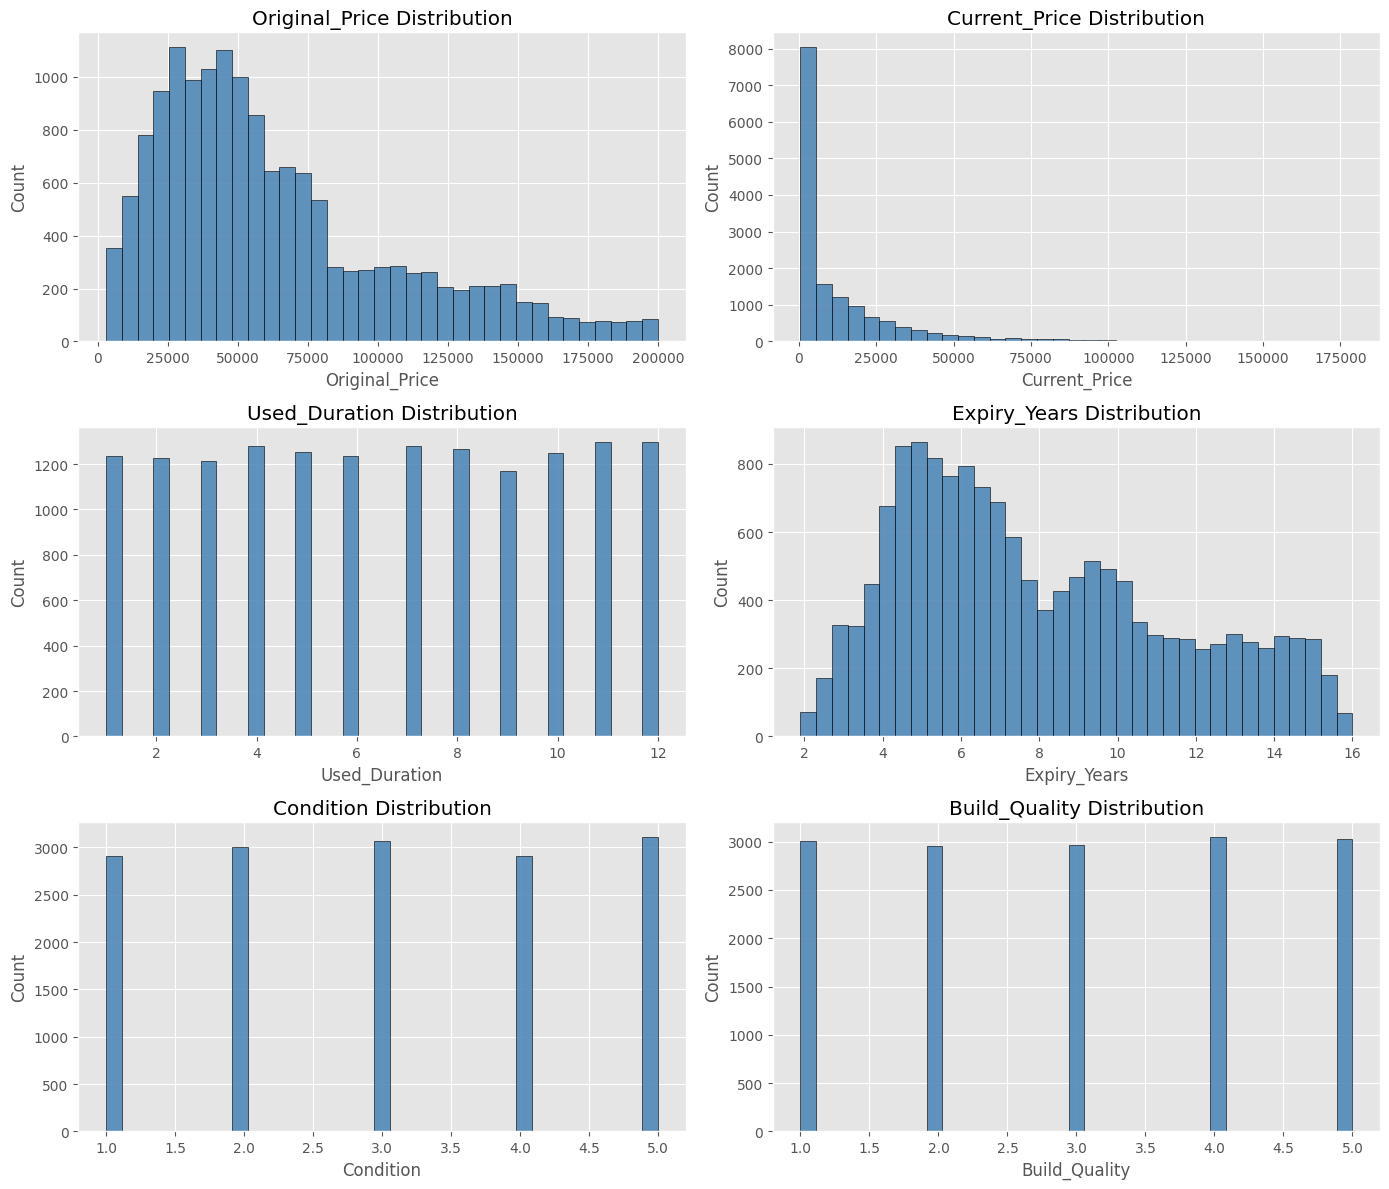

In [33]:
# Univariate numeric distributions
plot_cols = [
    'Original_Price', 'Current_Price', 'Used_Duration', 'Expiry_Years',
    'Condition', 'Build_Quality'
 ]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, c in enumerate(plot_cols):
    axes[i].hist(df[c], bins=35, color='steelblue', alpha=0.85, edgecolor='black')
    axes[i].set_title(f'{c} Distribution')
    axes[i].set_xlabel(c)
    axes[i].set_ylabel('Count')

# Hide any extra subplot axes
for j in range(len(plot_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

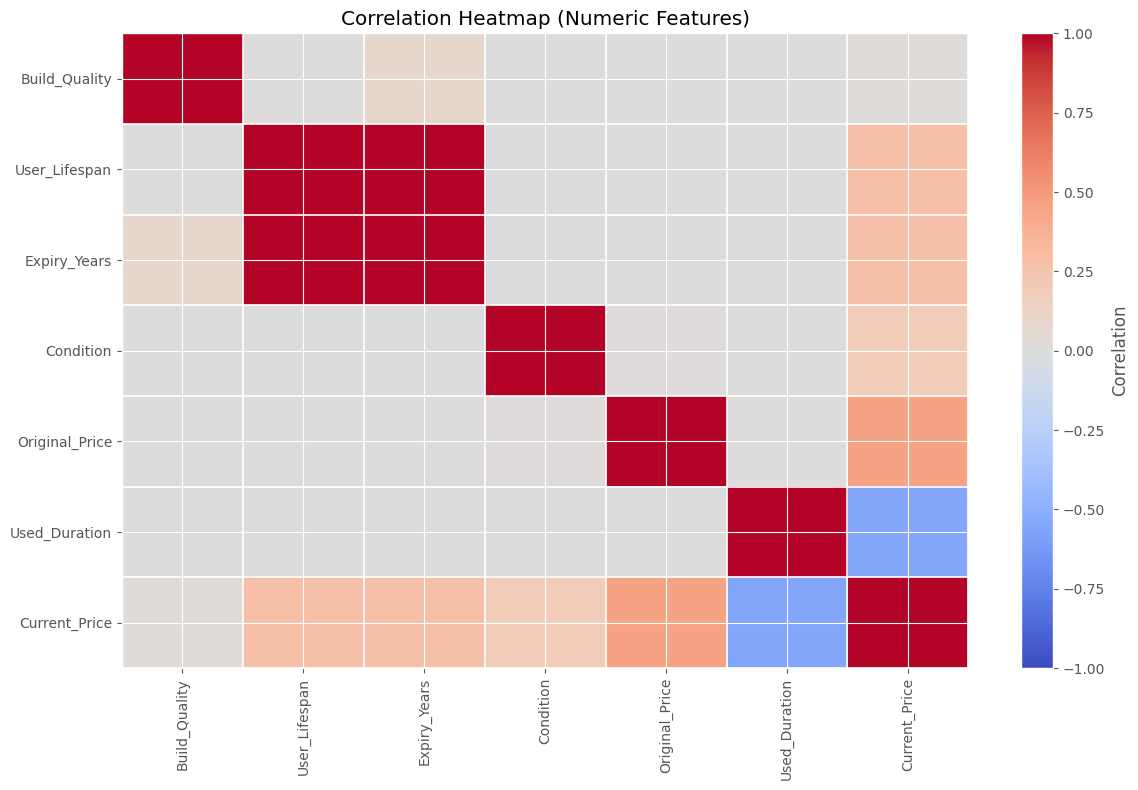

,corr_with_Current_Price
Current_Price,1.000000
Original_Price,0.452614
Expiry_Years,0.277923
User_Lifespan,0.277353
Condition,0.181345
Build_Quality,0.022520
Used_Duration,-0.549494


In [39]:
# Correlation matrix (numeric only)
corr_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
corr = df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(corr.values, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)

# Major ticks and labels
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_yticklabels(corr.columns)
ax.set_title('Correlation Heatmap (Numeric Features)')

# Draw cell gridlines so each color sits in a distinct box
ax.set_xticks(np.arange(-0.5, len(corr.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(corr.columns), 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=1.2)
ax.tick_params(which='minor', bottom=False, left=False)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlation')
plt.tight_layout()
plt.show()

display(corr['Current_Price'].sort_values(ascending=False).to_frame('corr_with_Current_Price'))

,Product_Type,count,avg_original_price,avg_current_price,median_current_price,avg_used_duration,avg_condition
9,TV,1247,105591.701684,34228.602670,25912.570,6.402566,2.999198
6,Refrigerator,1228,49901.922638,15773.170480,12893.680,6.545603,2.982085
1,DSLR Camera,1272,120351.751572,26437.501958,12611.115,6.577830,3.093553
0,Air Conditioner,1267,42060.176006,13820.939803,11830.900,6.397790,2.985793
11,Washing Machine,1237,36639.802749,11724.161504,9847.670,6.496362,2.973323
5,Microwave,1280,17443.207813,3908.048609,1684.630,6.433594,3.028125
3,Gaming Console,1209,55029.759305,8095.162366,500.000,6.661704,3.060380
2,Electric Scooter,1242,110067.089372,17941.002013,500.000,6.620773,3.046699
7,Smartphone,1234,63227.601297,5679.928509,500.000,6.611021,3.047002
4,Laptop,1235,89542.176518,11591.326907,500.000,6.554656,3.025911


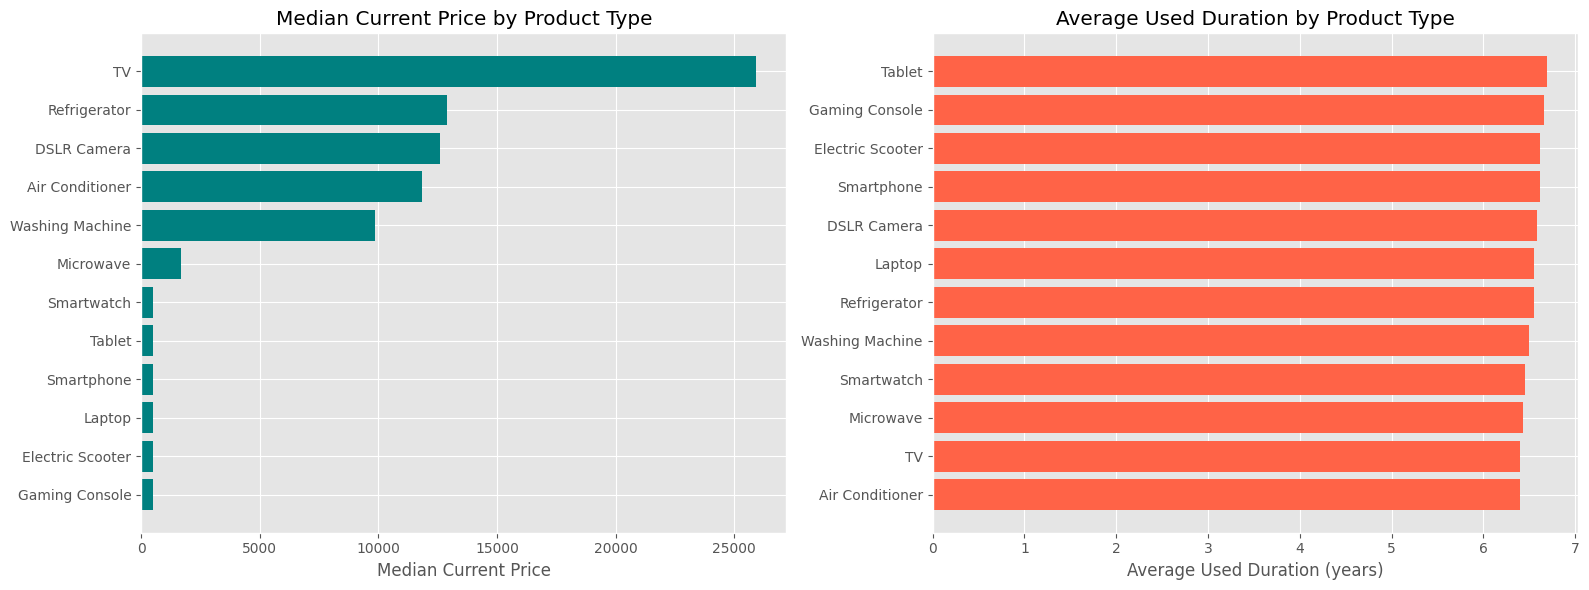

In [35]:
# Product-level pricing behavior
prod_stats = (
    df.groupby('Product_Type', as_index=False)
      .agg(
           count=('Product_Type', 'size'),
           avg_original_price=('Original_Price', 'mean'),
           avg_current_price=('Current_Price', 'mean'),
           median_current_price=('Current_Price', 'median'),
           avg_used_duration=('Used_Duration', 'mean'),
           avg_condition=('Condition', 'mean')
       )
      .sort_values('median_current_price', ascending=False)
)

display(prod_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

tmp = prod_stats.sort_values('median_current_price', ascending=True)
axes[0].barh(tmp['Product_Type'], tmp['median_current_price'], color='teal')
axes[0].set_title('Median Current Price by Product Type')
axes[0].set_xlabel('Median Current Price')

tmp2 = prod_stats.sort_values('avg_used_duration', ascending=True)
axes[1].barh(tmp2['Product_Type'], tmp2['avg_used_duration'], color='tomato')
axes[1].set_title('Average Used Duration by Product Type')
axes[1].set_xlabel('Average Used Duration (years)')

plt.tight_layout()
plt.show()

,Usage_Pattern,count,avg_used_duration,avg_current_price,median_current_price,avg_condition
0,Heavy,4984,6.507424,13133.425038,3700.635,3.032905
1,Light,5066,6.590209,13100.866332,4160.925,2.999408
2,Moderate,4950,6.512727,13100.055430,4573.360,3.029899


,Condition,count,avg_current_price,median_current_price,q1_current_price,q3_current_price
0,1,2908,7703.363343,2467.220,500.0,10042.2775
1,2,3006,10984.107059,3724.105,500.0,15266.3175
2,3,3065,12669.062166,4532.780,500.0,18620.6000
3,4,2911,15307.170890,5436.360,500.0,21926.8100
4,5,3110,18605.079482,6873.775,500.0,27285.8325


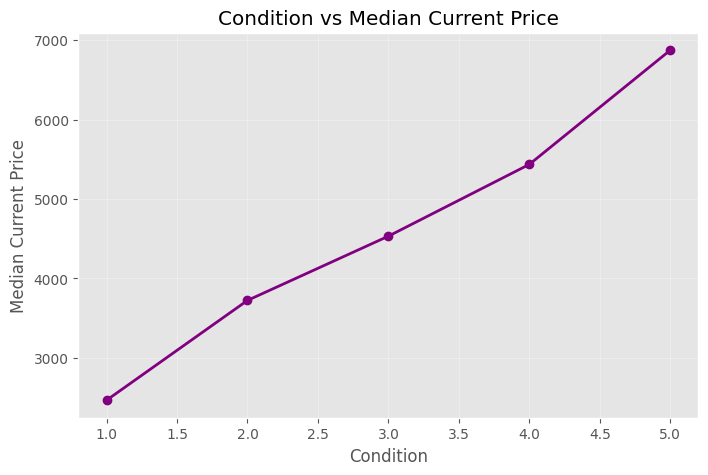

In [40]:
# Usage pattern and condition analysis
usage_stats = (
    df.groupby('Usage_Pattern', as_index=False)
      .agg(
           count=('Usage_Pattern', 'size'),
           avg_used_duration=('Used_Duration', 'mean'),
           avg_current_price=('Current_Price', 'mean'),
           median_current_price=('Current_Price', 'median'),
           avg_condition=('Condition', 'mean')
       )
      .sort_values('avg_current_price', ascending=False)
)
display(usage_stats)

cond_stats = (
    df.groupby('Condition', as_index=False)
      .agg(
           count=('Condition', 'size'),
           avg_current_price=('Current_Price', 'mean'),
           median_current_price=('Current_Price', 'median'),
           q1_current_price=('Current_Price', lambda s: s.quantile(0.25)),
           q3_current_price=('Current_Price', lambda s: s.quantile(0.75))
       )
      .sort_values('Condition')
)
display(cond_stats)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cond_stats['Condition'], cond_stats['median_current_price'], marker='o', linewidth=2, color='purple')
ax.set_title('Condition vs Median Current Price')
ax.set_xlabel('Condition')
ax.set_ylabel('Median Current Price')
ax.grid(True, alpha=0.3)
plt.show()

,feature,lower_bound,upper_bound,outlier_count,outlier_pct
1,Current_Price,-25555.37875,43925.63125,1137,7.58
0,Original_Price,-46342.62500,160352.37500,571,3.81
2,Used_Duration,-5.00000,19.00000,0,0.00
3,Expiry_Years,-2.45000,17.95000,0,0.00


Total rows flagged as outlier in at least one checked feature: 1432 (9.55%)
Potential anomaly rows where Used_Duration > Expiry_Years: 5987


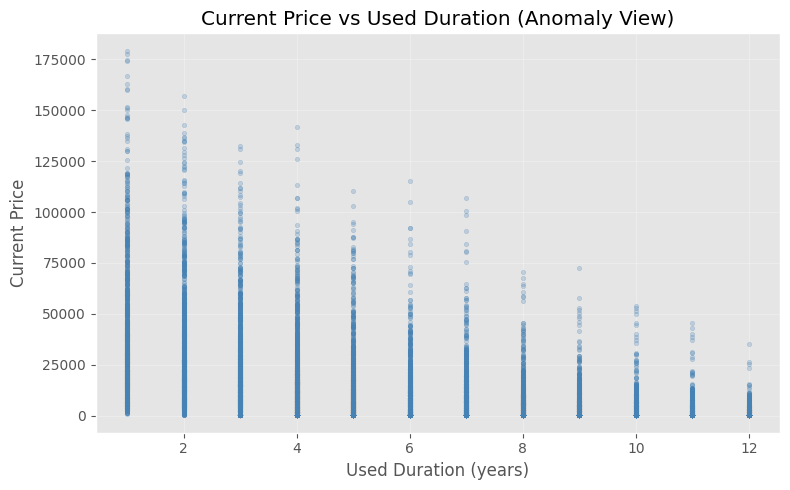

In [37]:
# Outlier and anomaly checks (IQR method)
check_cols = ['Original_Price', 'Current_Price', 'Used_Duration', 'Expiry_Years']
outlier_rows = pd.Series(False, index=df.index)
outlier_summary = []

for col in check_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df[col] < lower) | (df[col] > upper)
    outlier_rows |= mask
    outlier_summary.append({
        'feature': col,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': int(mask.sum()),
        'outlier_pct': round(mask.mean() * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('outlier_pct', ascending=False)
display(outlier_df)

print(f'Total rows flagged as outlier in at least one checked feature: {int(outlier_rows.sum())} ({outlier_rows.mean()*100:.2f}%)')
print(f'Potential anomaly rows where Used_Duration > Expiry_Years: {int((df["Used_Duration"] > df["Expiry_Years"]).sum())}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Used_Duration'], df['Current_Price'], s=10, alpha=0.25, color='steelblue')
ax.set_title('Current Price vs Used Duration (Anomaly View)')
ax.set_xlabel('Used Duration (years)')
ax.set_ylabel('Current Price')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()